# Predicting an employee's experience level with an SVM

This is the second half of the project. The goal is to predict an employee's **experience level** (entry, mid, senior, or executive) from salary and job information using a **Support Vector Machine (SVM)**.

The approach is straightforward: load the data, explore it briefly, prepare it for the model (one-hot encode the categories, scale the salary), train an SVM, tune its main setting `C`, and finally look at the per-class errors, which turn out to be the most revealing part of the task.

I created and ran it in Google Colab. The SVM is light enough to train on a single CPU, so unlike the image task it did not need the GPU cluster.

## 1. Setup

A few standard libraries: `pandas` for the table, `numpy` for the maths, and `matplotlib` for the plots.

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

## 2. Loading the data

The dataset is Salary Insights by Job Role (2024). The cell below downloads and unzips it directly from Kaggle. Alternatively, you can add `Dataset salary 2024.csv` into the session manually.

Kaggle: https://www.kaggle.com/datasets/zahranusrat/salary

In [3]:
#!/bin/bash
!curl -L -o ./salary.zip\
  https://www.kaggle.com/api/v1/datasets/download/zahranusrat/salary
!unzip salary.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  107k  100  107k    0     0   310k      0 --:--:-- --:--:-- --:--:--  310k
Archive:  salary.zip
  inflating: Dataset salary 2024.csv  


In [4]:
import os
# Make sure to upload the data in colab
# Importing our dataset
df = pd.read_csv("/content/Dataset salary 2024.csv")
df.head(5)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


## 3. Exploring the data

It helps to get a sense of the data first: which columns exist, what values they take, and how the salary relates to factors such as country and experience level. A few of these plots already hint at *why* the model will eventually struggle: the experience levels are very unevenly represented and overlap a lot on salary alone.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           16534 non-null  int64 
 1   experience_level    16534 non-null  object
 2   employment_type     16534 non-null  object
 3   job_title           16534 non-null  object
 4   salary              16534 non-null  int64 
 5   salary_currency     16534 non-null  object
 6   salary_in_usd       16534 non-null  int64 
 7   employee_residence  16534 non-null  object
 8   remote_ratio        16534 non-null  int64 
 9   company_location    16534 non-null  object
 10  company_size        16534 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.4+ MB


In [6]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [7]:
# unique entries in experience_level

print(df['experience_level'].unique())

['SE' 'MI' 'EN' 'EX']


In [8]:
for i in df.columns:
  print(i)
  print(df[i].unique())

work_year
[2024 2022 2023 2020 2021]
experience_level
['SE' 'MI' 'EN' 'EX']
employment_type
['FT' 'CT' 'PT' 'FL']
job_title
['AI Engineer' 'Data Engineer' 'Machine Learning Engineer' 'ML Engineer'
 'Data Analyst' 'NLP Engineer' 'Data Scientist' 'Applied Scientist'
 'Data Manager' 'Data Architect' 'Data Operations Manager'
 'Research Scientist' 'Data Science Manager'
 'Business Intelligence Engineer' 'Business Intelligence' 'Data Modeler'
 'Data Integration Specialist' 'Data Product Manager'
 'Data Visualization Specialist' 'Data Science' 'Data Specialist'
 'Business Intelligence Lead' 'Research Analyst'
 'Business Intelligence Analyst' 'AI Software Engineer'
 'Machine Learning Scientist' 'Data Science Engineer'
 'Machine Learning Operations Engineer' 'Analytics Engineer'
 'Data Management Analyst' 'Encounter Data Management Professional'
 'Data Analytics Specialist' 'Head of Data' 'Data Analytics Lead'
 'Research Engineer' 'AI Scientist' 'Business Intelligence Developer'
 'Machine Lear

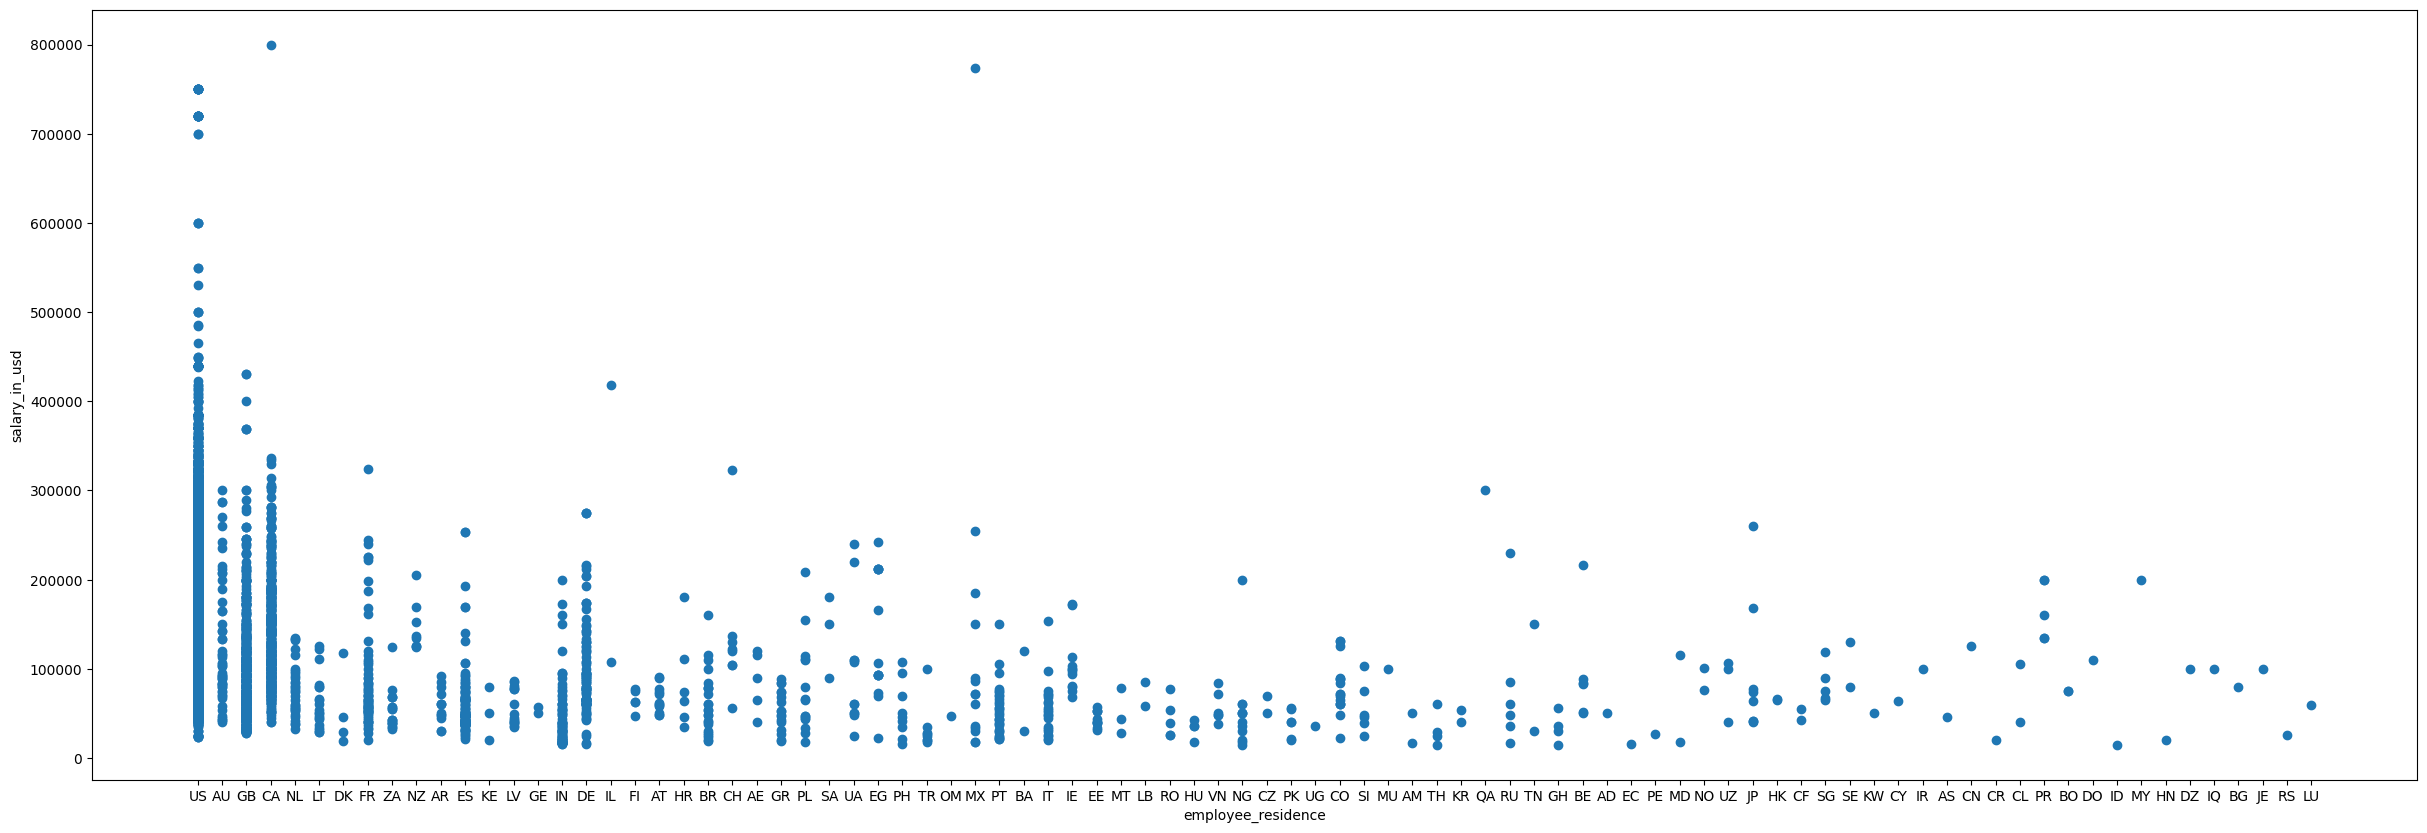

In [9]:
# First look: does salary depend on the country the employee lives in? Each dot
# is one person. The figure is very wide because there are many countries.
plt.figure(figsize=(30,10))
plt.scatter(df['employee_residence'], df['salary_in_usd'])
plt.xlabel('employee_residence')
plt.ylabel('salary_in_usd')
plt.show()

In [10]:
# Average salary and its spread for each country, so we can compare typical pay
# across residences instead of the raw cloud of dots.
means = df.groupby('employee_residence')['salary_in_usd'].mean()
stds = df.groupby('employee_residence')['salary_in_usd'].std()

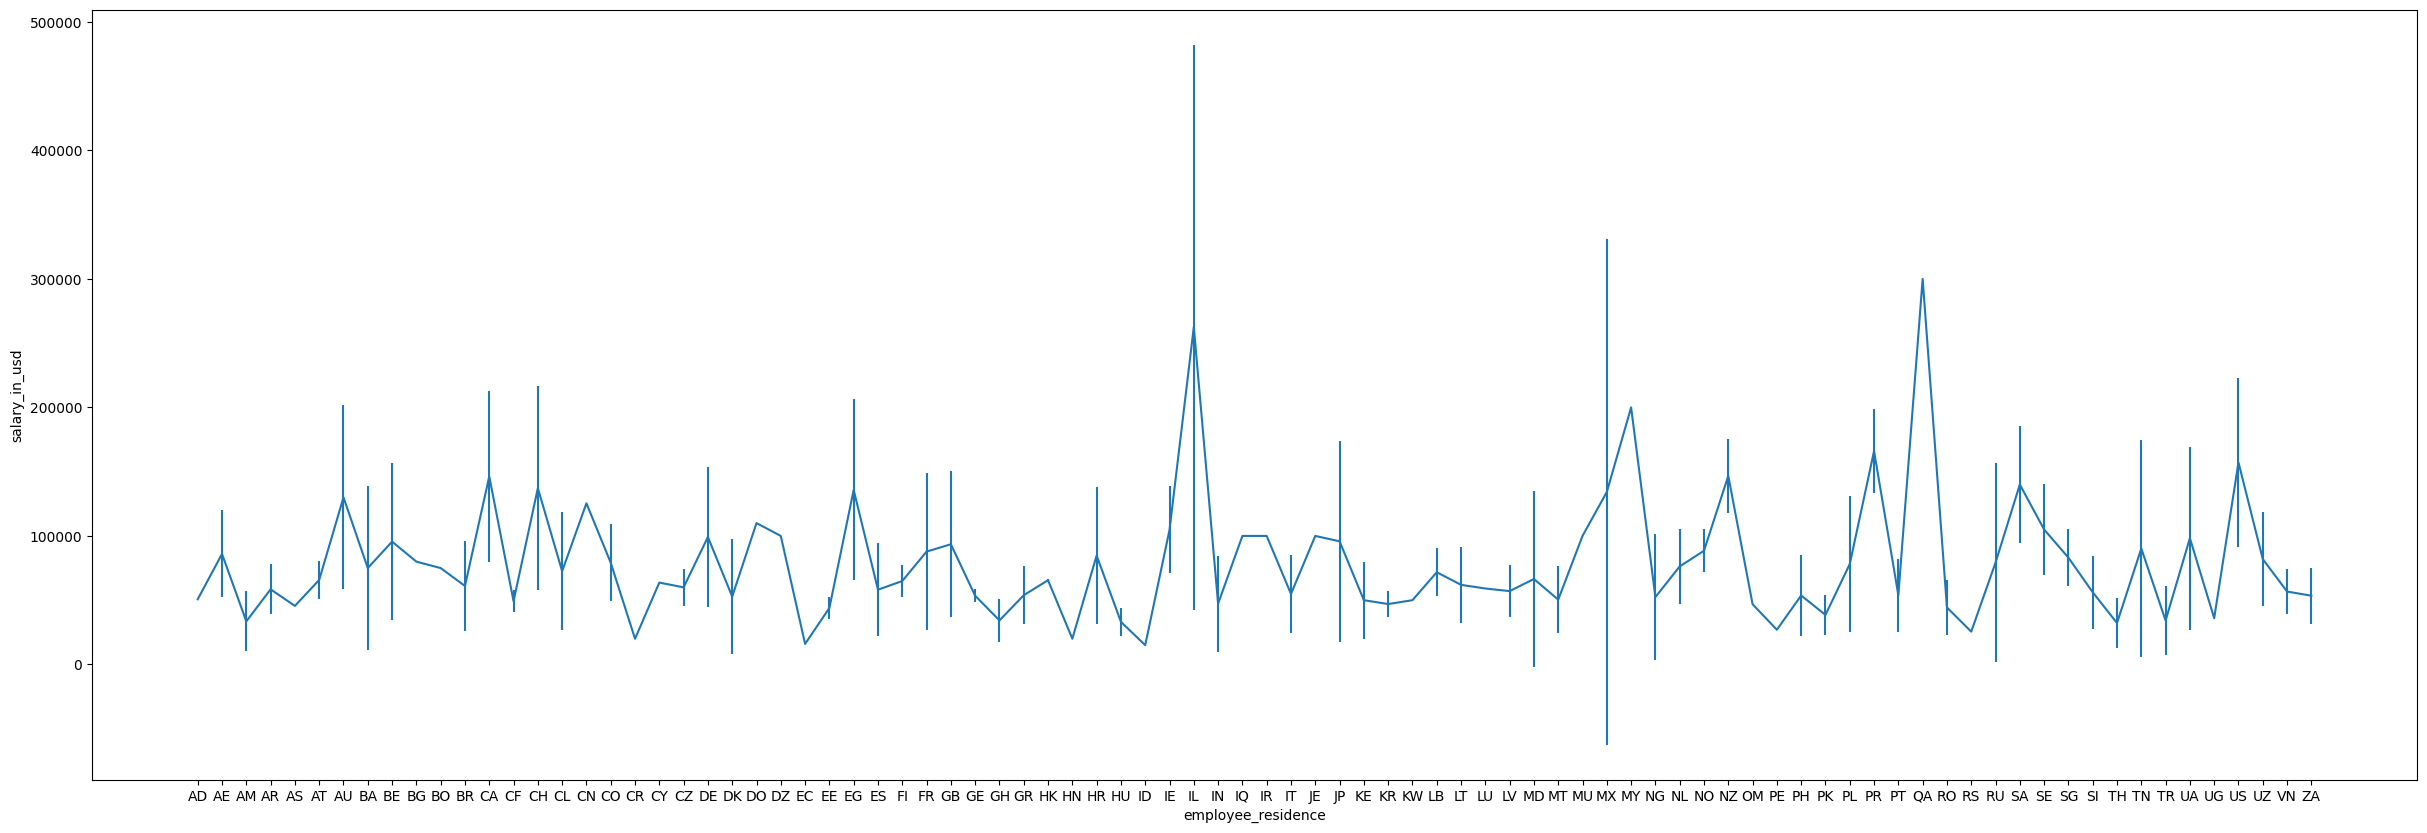

In [11]:
# Same information as above, drawn as a line with error bars: the line is the
# mean salary per country and the bars show the spread, one std each way.
plt.figure(figsize=(30,10))
plt.errorbar(means.index, means, yerr=stds)

plt.xlabel('employee_residence')
plt.ylabel('salary_in_usd')
plt.show()

<Axes: xlabel='employee_residence'>

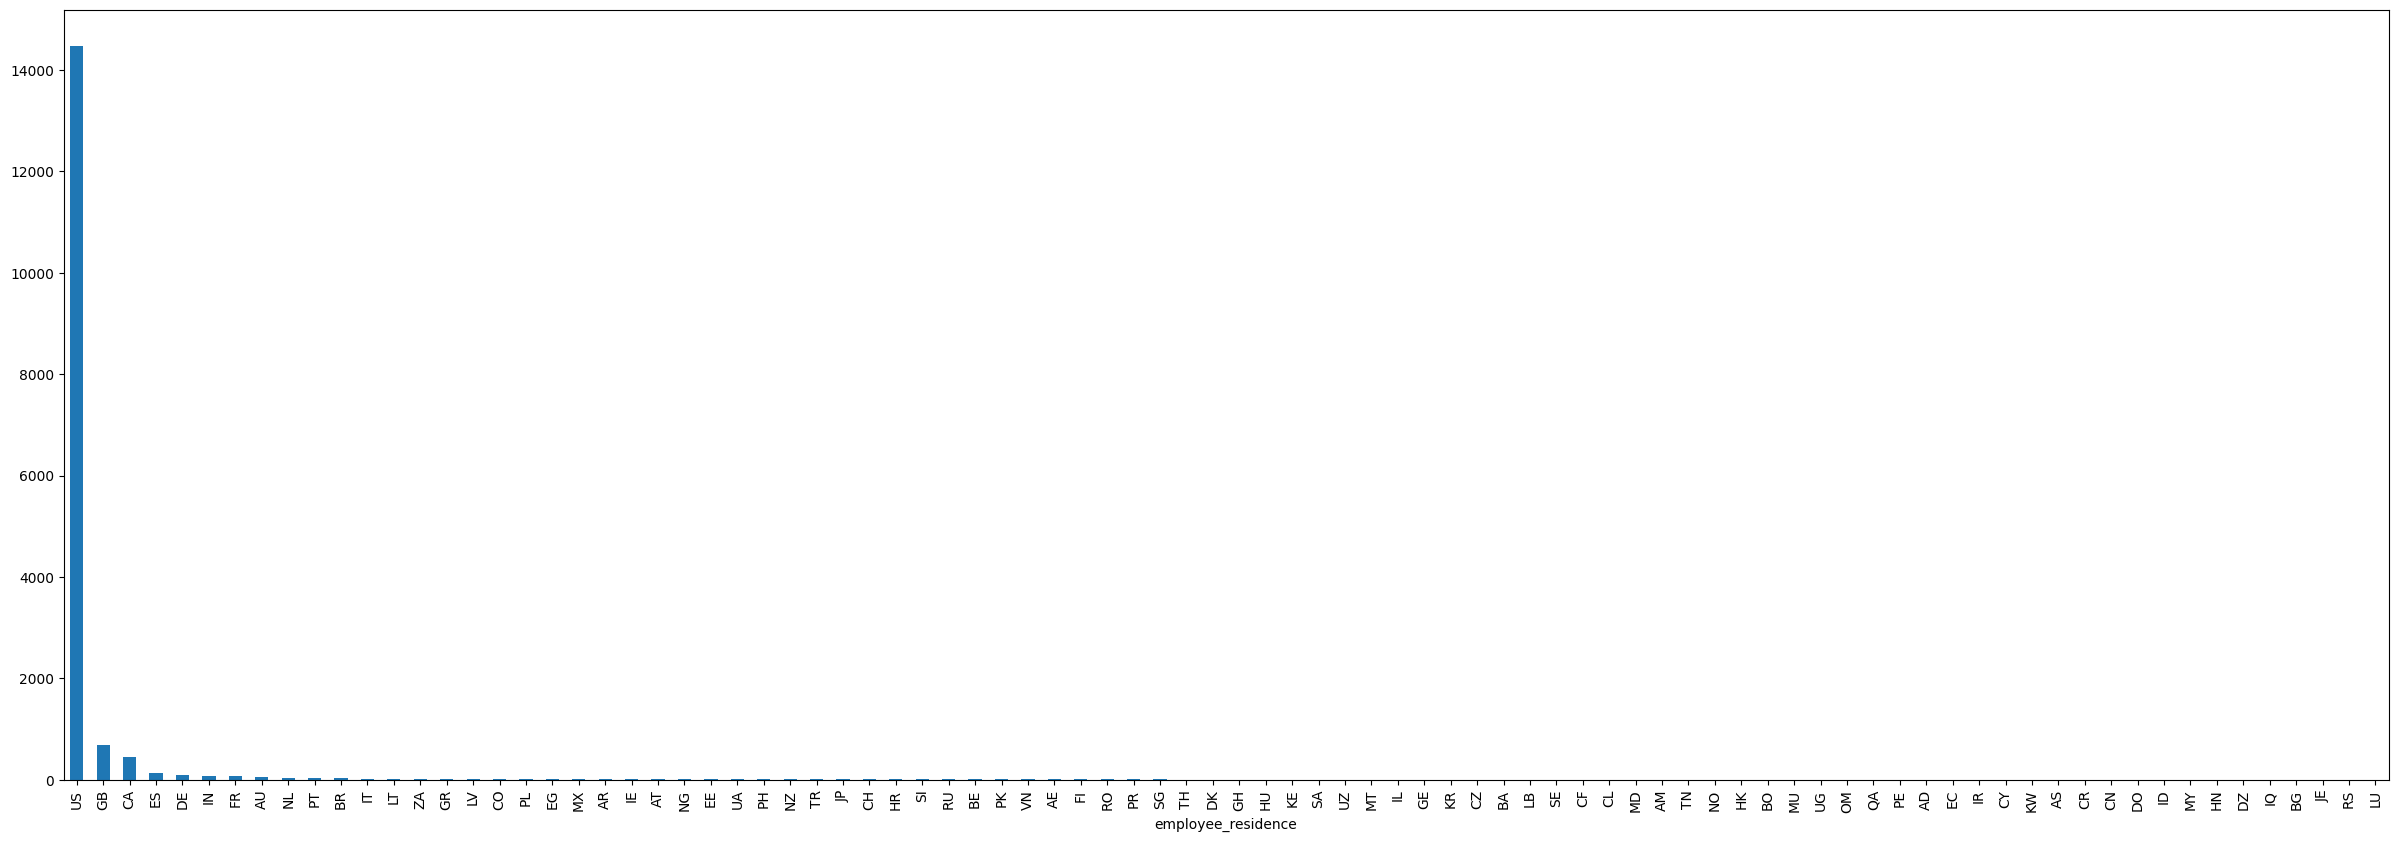

In [12]:
# How many rows we have per country. This matters: countries with very few
# samples can't really be learned, and we one-hot encode them later.
plt.figure(figsize=(30,10))
df['employee_residence'].value_counts().plot(kind='bar')

<Axes: xlabel='company_location'>

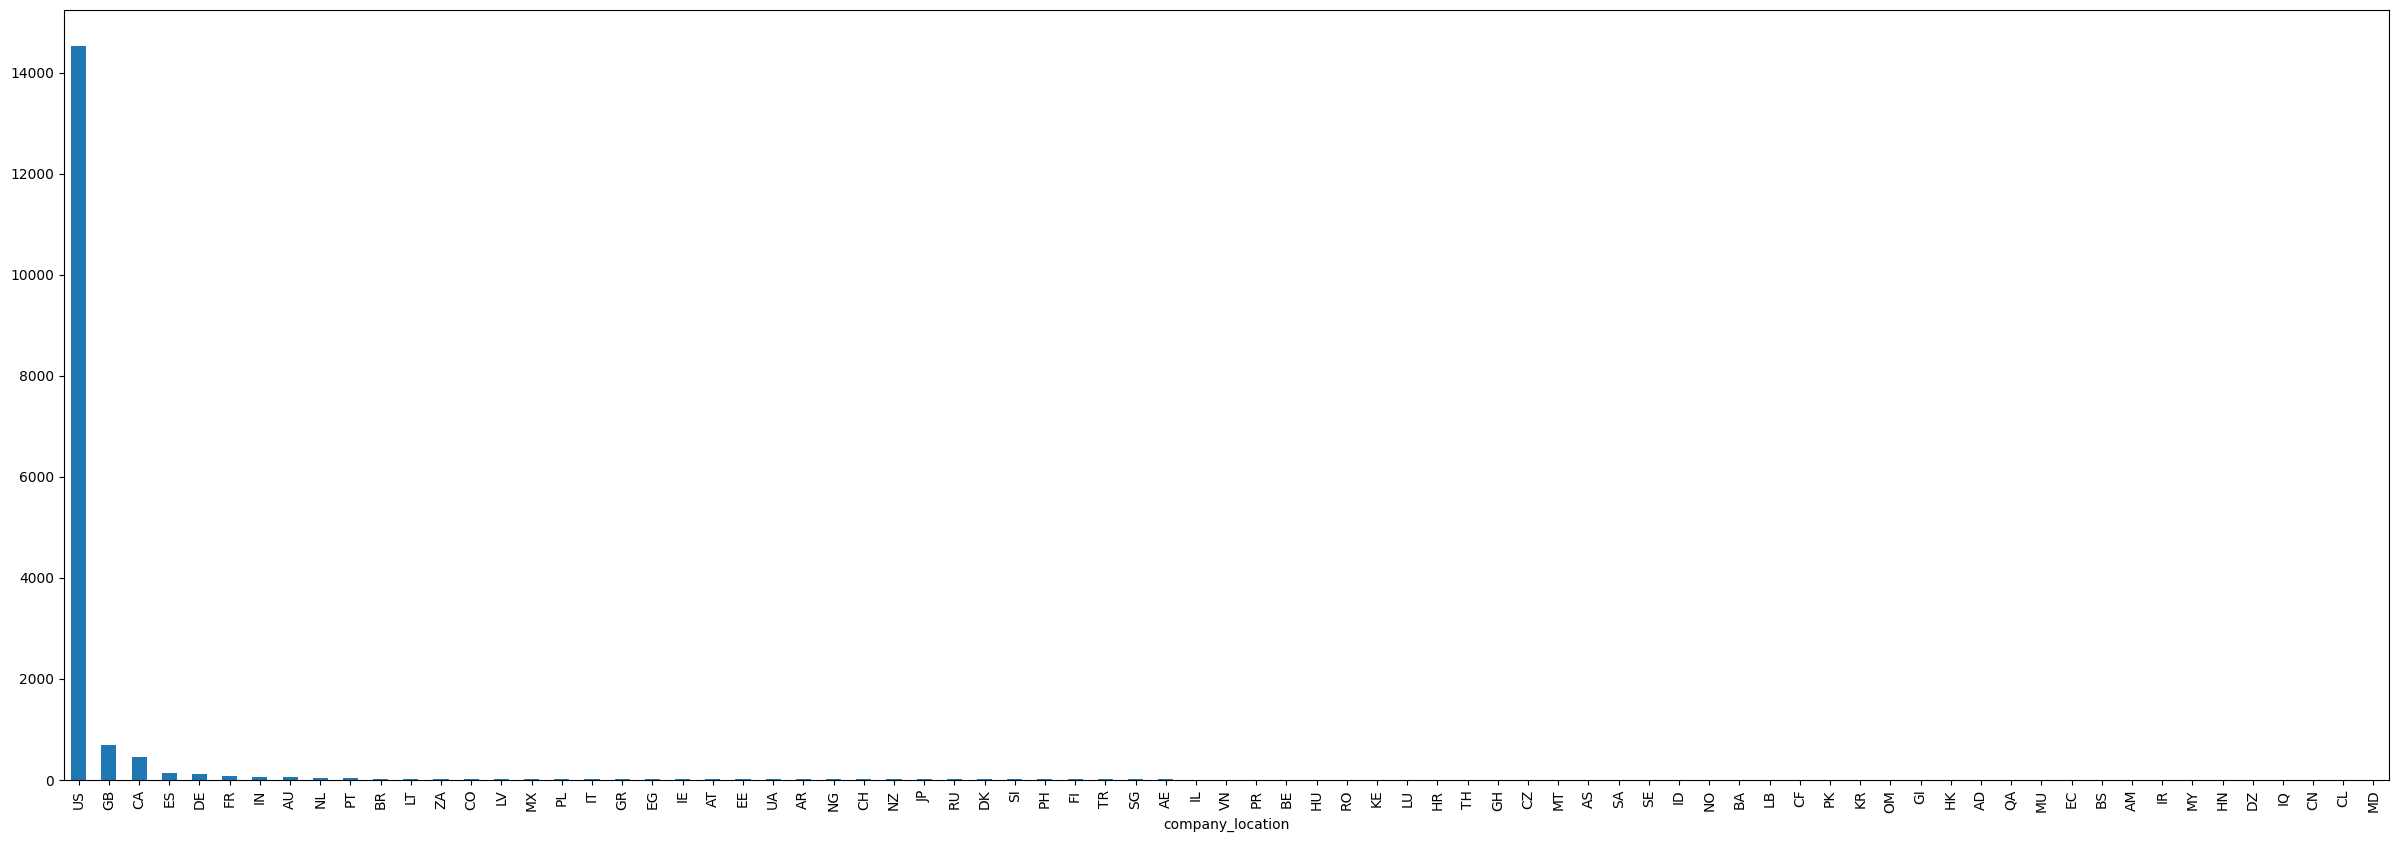

In [13]:
# Same count, but for the company's location instead of the employee's.
plt.figure(figsize=(30,10))
df['company_location'].value_counts().plot(kind='bar')

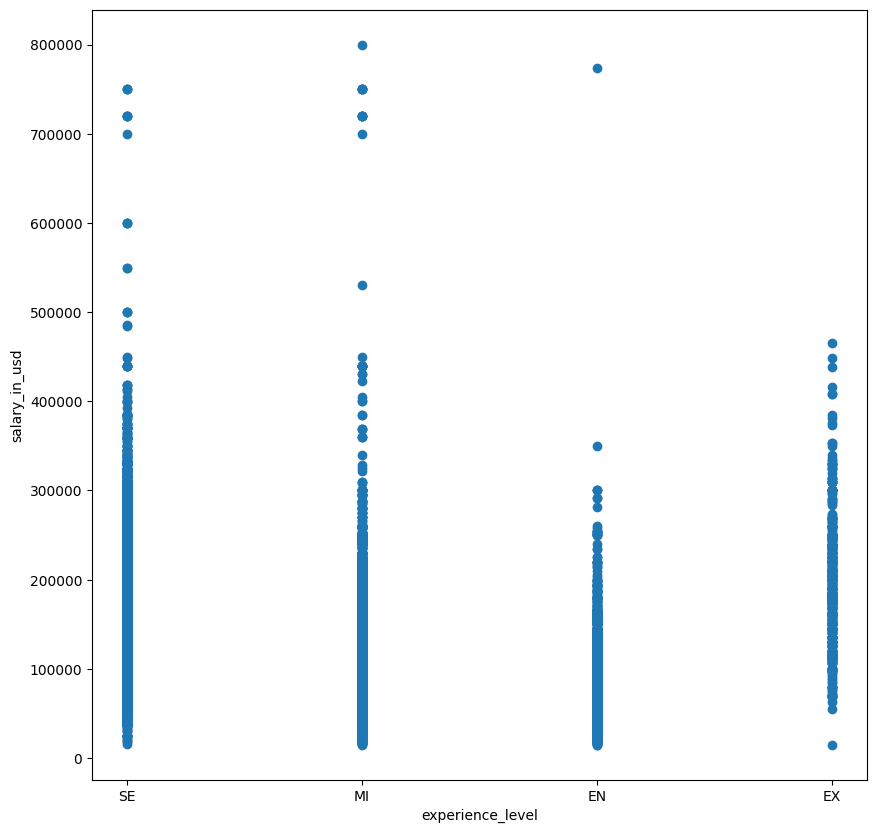

In [14]:
# The relationship we care about: salary against experience level. The four
# levels overlap a lot on salary alone, which warns us that predicting the level
# will not be easy.
plt.figure(figsize=(10,10))
plt.scatter(df['experience_level'], df['salary_in_usd'])
plt.xlabel('experience_level')
plt.ylabel('salary_in_usd')
plt.show()

## 4. Preparing the data

The SVM needs numbers, a scale, and a clear separation between the inputs and what we are predicting. So we one-hot encode the category columns, normalize the salary, remove the columns we don't need, and keep 'experience_level' as the label.

In [ ]:
# The SVM only understands numbers, so the category columns must become numbers
# first. These columns have no natural order (work year, remote-work ratio,
# company size, company location), so we use one-hot encoding: every value gets
# its own 0/1 column. That way the model never assumes one country is "greater"
# than another just because of how it was numbered.
#
# experience_level is deliberately NOT in this list, because it is the answer we
# are trying to predict.
onehot_fields = ['work_year', 'remote_ratio', 'company_size', 'company_location']

for field in onehot_fields:
    dummies = pd.get_dummies(df[field], prefix=field, drop_first=False)
    df = pd.concat([df, dummies], axis=1)

# Once we have the new 0/1 columns, the original text columns are redundant, so drop them.
df = df.drop(onehot_fields, axis=1)
df.head()

In [ ]:
# Salary in USD runs into the hundreds of thousands, while every other column is
# now a 0 or a 1. An SVM compares points by distance, so a column with huge
# values would drown out the 0/1 columns. To prevent that we standardize the
# salary: subtract its mean and divide by its standard deviation, which re-centers
# it around 0 with a spread of about 1, the same range as the one-hot columns.
continuous_fields = ['salary_in_usd']

# Keep the mean and std in case we want to turn a scaled value back into dollars.
scaled_features = {}

for field in continuous_fields:
    mean = df[field].mean()
    std = df[field].std()
    scaled_features[field] = [mean, std]
    # Cast to float first, otherwise pandas warns about dividing integers.
    df[field] = (df[field].astype(float) - mean) / std

df.head()

In [17]:
df.columns

Index(['employment_type', 'job_title', 'salary', 'salary_currency',
       'salary_in_usd', 'employee_residence', 'work_year_2020',
       'work_year_2021', 'work_year_2022', 'work_year_2023', 'work_year_2024',
       'experience_level_EN', 'experience_level_EX', 'experience_level_MI',
       'experience_level_SE', 'remote_ratio_0', 'remote_ratio_50',
       'remote_ratio_100', 'company_size_L', 'company_size_M',
       'company_size_S', 'company_location_AD', 'company_location_AE',
       'company_location_AM', 'company_location_AR', 'company_location_AS',
       'company_location_AT', 'company_location_AU', 'company_location_BA',
       'company_location_BE', 'company_location_BR', 'company_location_BS',
       'company_location_CA', 'company_location_CF', 'company_location_CH',
       'company_location_CL', 'company_location_CN', 'company_location_CO',
       'company_location_CZ', 'company_location_DE', 'company_location_DK',
       'company_location_DZ', 'company_location_EC', 'co

In [ ]:
# Keep a full copy of the table before trimming it, in case we want to go back.
df_backup = df.copy()

# Some columns aren't useful as inputs: employment_type and job_title are
# free text we didn't encode, 'salary' is the raw amount in the original currency
# (we kept the cleaned-up salary_in_usd instead), and salary_currency and
# employee_residence are extra text. Drop those and keep everything else,
# including experience_level, which stays because it is our label.
fields_to_drop = ['employment_type', 'job_title', 'salary', 'salary_currency', 'employee_residence']

df = df.drop(fields_to_drop, axis=1)
df.head()

## 5. Training a first SVM

We split the data into a training and a test part, then fit a first SVM with the default `C=1` to get a baseline before any tuning.

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Pull out the label (what we want to predict).
labels = df['experience_level']

# Everything that's left becomes the input features.
features = df.drop('experience_level', axis=1)

# Hold back 20% of the rows as a test set, so we can check the model on data it
# has never seen. random_state fixes the shuffle so the split is identical every
# run. stratify=labels keeps the four experience levels in the same proportions in
# both parts. Without it, a rare class like 'executive' might barely appear in one.
features_train, features_test, labels_train, labels_test = train_test_split(
    features, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels,
)

print("Training samples:", len(features_train))
print("Test samples:    ", len(features_test))
print("Number of features per sample:", features.shape[1])

# Set up the SVM. An RBF kernel lets the boundary curve around the data instead
# of being a straight line. C controls the trade-off between a smooth, simple
# boundary and getting every training point right. We start at C=1 and search for
# a better value below.
svm_model = SVC(kernel='rbf', C=1.0)
svm_model

In [ ]:
# Train the SVM on the training set and time it, since an RBF SVM on ~13,000 rows
# is not instant.
start_time = time.time()
svm_model.fit(features_train, labels_train)
seconds_taken = time.time() - start_time

# score() returns accuracy: the fraction of samples labeled correctly. We check
# both sets, since a big gap between train and test accuracy would point to overfitting.
train_accuracy = svm_model.score(features_train, labels_train)
test_accuracy = svm_model.score(features_test, labels_test)

print(f"Training took {seconds_taken:.1f} seconds")
print(f"Accuracy on the training data: {train_accuracy:.3f}")
print(f"Accuracy on the test data:     {test_accuracy:.3f}")

## 6. Choosing C and reading the errors per class

`C` is the SVM's most important setting, so we try a range of values and keep the best. We then look at the per-class precision, recall, and confusion matrix for that best model. This is where the real story of the task shows up.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# C is the most important setting for an SVM, so we try values across several
# orders of magnitude and keep the one with the best test accuracy. A small C
# keeps the boundary smooth and forgives mistakes, whereas a large C pushes to get every
# training point right, which risks overfitting. Each fit is slow, so this cell
# takes a while.
c_values = [0.01, 0.1, 1, 10, 100]
test_accuracies = []

for c in c_values:
    model = SVC(kernel='rbf', C=c)
    model.fit(features_train, labels_train)
    accuracy = model.score(features_test, labels_test)
    test_accuracies.append(accuracy)
    print(f"C = {c:<6} -> test accuracy = {accuracy:.3f}")

# Plot accuracy against C. The x-axis is on a log scale because C grows by powers of ten.
plt.figure(figsize=(8, 5))
plt.plot(c_values, test_accuracies, marker='o')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Test accuracy')
plt.title('SVM test accuracy for different values of C')
plt.grid(True)
plt.show()

# Take whichever C scored best and study that model more closely.
best_index = test_accuracies.index(max(test_accuracies))
best_c = c_values[best_index]
print("\nBest C:", best_c, "with test accuracy", round(max(test_accuracies), 3))

best_model = SVC(kernel='rbf', C=best_c)
best_model.fit(features_train, labels_train)
predictions = best_model.predict(features_test)

# The classification report breaks the score down per class: precision (when it
# says class X, how often it's right), recall (of all the real class X, how many
# it found), and F1 (a blend of the two). This is where the class imbalance shows.
print("\nResults per class:\n")
print(classification_report(labels_test, predictions))

# The confusion matrix shows, for each true class (rows), how the predictions
# spread across the classes (columns). The diagonal is correct, while everything off it
# is a mix-up.
class_order = ['EN', 'MI', 'SE', 'EX']
matrix = confusion_matrix(labels_test, predictions, labels=class_order)

display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=class_order)
display.plot(cmap='Blues')
plt.title(f'Confusion matrix (C = {best_c})')
plt.show()

## 7. Handling the class imbalance

The results above look reasonable overall, but the SVM largely guesses *senior* because that one class accounts for almost two-thirds of the data. The fix is to make the SVM care more about the rare classes by retraining with `class_weight='balanced'`, which weights each class inversely to how often it appears. We keep the best `C` and change only this, so any difference is due to the weighting alone. We expect overall accuracy to drop while recall on the rare classes (entry, mid, executive) rises.

In [ ]:
# Same kernel and same best C as before, but now with balanced class weights.
balanced_model = SVC(kernel='rbf', C=best_c, class_weight='balanced')
balanced_model.fit(features_train, labels_train)
balanced_predictions = balanced_model.predict(features_test)

# Compare the overall accuracy of the plain model and the balanced one.
balanced_accuracy = balanced_model.score(features_test, labels_test)
print(f"Plain SVM    (C={best_c}) test accuracy: {max(test_accuracies):.3f}")
print(f"Balanced SVM (C={best_c}) test accuracy: {balanced_accuracy:.3f}")

# Per-class report again: this is the part we care about. Watch the recall column
# for EN, MI, and EX, which was tiny for the plain model.
print("\nResults per class (class_weight='balanced'):\n")
print(classification_report(labels_test, balanced_predictions))

# Confusion matrix for the balanced model, to compare with the earlier one.
balanced_matrix = confusion_matrix(labels_test, balanced_predictions, labels=class_order)
balanced_display = ConfusionMatrixDisplay(confusion_matrix=balanced_matrix, display_labels=class_order)
balanced_display.plot(cmap='Blues')
plt.title(f"Confusion matrix with class_weight='balanced' (C = {best_c})")
plt.show()